# Ejercicios — Bits, Cúbits y Algoritmos Cuánticos

1. **Ejercicio 1**: Creación de los estados de Bell $|\beta_{01}\rangle$, $|\beta_{10}\rangle$, $|\beta_{11}\rangle$.
2. **Ejercicio 2**: Algoritmo de Grover para encontrar las soluciones de una función lógica.


## Instalación y configuración

In [1]:
# Instalamos qiskit
!pip install -q "qiskit[visualization]" qiskit-aer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 62.4 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCMTGate, XGate, ZGate
from qiskit.circuit.gate import Gate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram


---
# Ejercicio 1: Creación de los estados de Bell

Los cuatro estados de Bell son:

$$
|\beta_{00}\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}, \quad
|\beta_{01}\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}, \quad
|\beta_{10}\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}, \quad
|\beta_{11}\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}
$$

$|\beta_{00}\rangle$ se obtiene con una puerta H en el cúbit de control seguida de una CNOT.
El resto se obtienen aplicando $Z^iX^j$ al cúbit *target* de $|\beta_{00}\rangle$:

$$
|\beta_{ij}\rangle = (I\otimes Z^iX^j)|\beta_{00}\rangle
$$


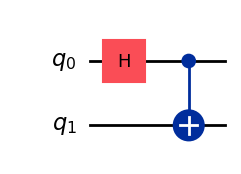

<IPython.core.display.Latex object>

In [ ]:
# |beta_00> = (|00> + |11>) / sqrt(2)
qc_beta00 = QuantumCircuit(2)
qc_beta00.h(0)
qc_beta00.cx(0, 1)
display(qc_beta00.draw('mpl'))

beta00 = Statevector.from_circuit(qc_beta00)
beta00.draw('latex', prefix="|\\beta_{00}\\rangle = ")


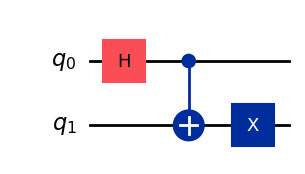

<IPython.core.display.Latex object>

In [4]:
# |beta_01> = (I ⊗ X) |beta_00>  -> aplicamos X al cubit target
qc_beta01 = QuantumCircuit(2)
qc_beta01.h(0)
qc_beta01.cx(0, 1)
qc_beta01.x(1)
display(qc_beta01.draw('mpl'))

beta01 = Statevector.from_circuit(qc_beta01)
beta01.draw('latex', prefix="|\\beta_{01}\\rangle = ")


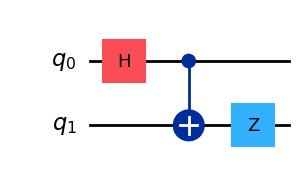

<IPython.core.display.Latex object>

In [5]:
# |beta_10> = (I ⊗ Z) |beta_00>  -> aplicamos Z al cubit target
qc_beta10 = QuantumCircuit(2)
qc_beta10.h(0)
qc_beta10.cx(0, 1)
qc_beta10.z(1)
display(qc_beta10.draw('mpl'))

beta10 = Statevector.from_circuit(qc_beta10)
beta10.draw('latex', prefix="|\\beta_{10}\\rangle = ")


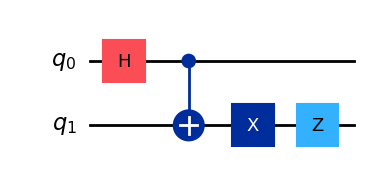

<IPython.core.display.Latex object>

In [6]:
# |beta_11> = (I ⊗ ZX) |beta_00>  -> aplicamos X y despues Z al cubit target
qc_beta11 = QuantumCircuit(2)
qc_beta11.h(0)
qc_beta11.cx(0, 1)
qc_beta11.x(1)
qc_beta11.z(1)
display(qc_beta11.draw('mpl'))

beta11 = Statevector.from_circuit(qc_beta11)
beta11.draw('latex', prefix="|\\beta_{11}\\rangle = ")


---
# Ejercicio 2: Algoritmo de Grover

Buscamos las soluciones de la función lógica:

$$
f(a_2,a_1,a_0)=(a_0\lor a_1)\land(\lnot a_0\lor a_2)\land(\lnot a_1\lor \lnot a_2)
$$

## Solución clásica (fuerza bruta)

Primero comprobamos cuántas soluciones tiene $f$, para poder calcular el número óptimo de
iteraciones del algoritmo de Grover.


In [7]:
# Obtenemos las soluciones por fuerza bruta
def f_clasica(a2, a1, a0):
    clausula_1 = a0 or a1
    clausula_2 = (not a0) or a2
    clausula_3 = (not a1) or (not a2)
    return clausula_1 and clausula_2 and clausula_3

print("Evaluando combinaciones (a2, a1, a0):")
print("-" * 40)

soluciones = []
for a2 in [0, 1]:
    for a1 in [0, 1]:
        for a0 in [0, 1]:
            if f_clasica(bool(a2), bool(a1), bool(a0)):
                soluciones.append((a2, a1, a0))
                print(f"Solución encontrada -> a2:{a2}, a1:{a1}, a0:{a0}")

print("-" * 40)
print(f"Número total de soluciones: {len(soluciones)}")


Evaluando combinaciones (a2, a1, a0):
----------------------------------------
Solución encontrada -> a2:0, a1:1, a0:0
Solución encontrada -> a2:1, a1:0, a0:1
----------------------------------------
Número total de soluciones: 2


## Implementación cuántica

Reutilizamos las puertas `AndGate` y `OrGate` reversibles del notebook `02. Bits y Cúbits`
para construir el oráculo de $f$, evaluándolo para las 8 combinaciones de 3 bits **en
paralelo** mediante superposición cuántica.


In [8]:
# Puertas AND / OR reversibles (reutilizadas del notebook 02. Bits y Cúbits)
def AndGate(n_controles: int) -> Gate:
    qc_and = QuantumCircuit(n_controles + 1)
    qc_and.append(MCMTGate(XGate(), n_controles, 1), range(n_controles + 1))
    return qc_and.to_gate(label='AND')

def OrGate(n_controles: int) -> Gate:
    qc_or = QuantumCircuit(n_controles + 1)
    qc_or.x(range(n_controles))
    qc_or.append(MCMTGate(XGate(), n_controles, 1), range(n_controles + 1))
    qc_or.x(n_controles)
    qc_or.x(range(n_controles))
    return qc_or.to_gate(label='OR')


In [9]:
# Oraculo de f(a2,a1,a0) = (a0 OR a1) AND (NOT a0 OR a2) AND (NOT a1 OR NOT a2)
#
# Distribucion de cubits del oraculo (7 cubits):
#   0 = a0, 1 = a1, 2 = a2        (entradas)
#   3 = anc_t1  ->  a0 OR a1
#   4 = anc_t2  ->  (NOT a0) OR a2
#   5 = anc_t3  ->  (NOT a1) OR (NOT a2)
#   6 = salida  ->  f(a2,a1,a0) = t1 AND t2 AND t3
N_INPUT = 3
N_ANC = 3
N_ORACLE = N_INPUT + N_ANC + 1  # = 7

def oraculo_f(inverso: bool) -> Gate:
    qc = QuantumCircuit(N_ORACLE)

    if not inverso:  # Computacion
        qc.append(OrGate(2), [0, 1, 3])          # t1 = a0 OR a1
        qc.x(0)
        qc.append(OrGate(2), [0, 2, 4])          # t2 = (NOT a0) OR a2
        qc.x(0)
        qc.x(1); qc.x(2)
        qc.append(OrGate(2), [1, 2, 5])          # t3 = (NOT a1) OR (NOT a2)
        qc.x(1); qc.x(2)
        qc.append(AndGate(3), [3, 4, 5, 6])      # f = t1 AND t2 AND t3
        gate = qc.to_gate(label="Oraculo_f")

    else:  # Descomputacion (mismas puertas autoinversas, orden inverso)
        qc.append(AndGate(3), [3, 4, 5, 6])
        qc.x(1); qc.x(2)
        qc.append(OrGate(2), [1, 2, 5])
        qc.x(1); qc.x(2)
        qc.x(0)
        qc.append(OrGate(2), [0, 2, 4])
        qc.x(0)
        qc.append(OrGate(2), [0, 1, 3])
        gate = qc.to_gate(label="Oraculo_f_inv")

    return gate


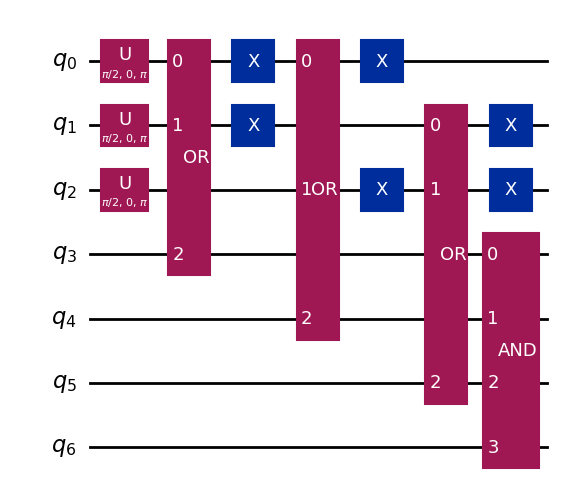

a2=1 a1=1 a0=0  ->  f=0   (prob=0.1250)
a2=1 a1=1 a0=1  ->  f=0   (prob=0.1250)
a2=0 a1=0 a0=1  ->  f=0   (prob=0.1250)
a2=0 a1=1 a0=1  ->  f=0   (prob=0.1250)
a2=0 a1=0 a0=0  ->  f=0   (prob=0.1250)
a2=1 a1=0 a0=0  ->  f=0   (prob=0.1250)
a2=0 a1=1 a0=0  ->  f=1   (prob=0.1250)
a2=1 a1=0 a0=1  ->  f=1   (prob=0.1250)


In [10]:
# Comprobacion EN PARALELO: ponemos las 3 entradas en superposicion y
# observamos que el cubit de salida queda entrelazado con f(a) para las
# 8 combinaciones a la vez.
qc_test = QuantumCircuit(N_ORACLE)
qc_test.h(range(N_INPUT))
qc_test.append(oraculo_f(inverso=False), range(N_ORACLE))
display(qc_test.decompose().draw('mpl'))

estado = Statevector.from_circuit(qc_test)
for cadena, prob in estado.probabilities_dict().items():
    if prob > 1e-6:
        # cadena: q6 q5 q4 q3 q2 q1 q0  (bit mas significativo a la izquierda)
        a0, a1, a2, salida = cadena[6], cadena[5], cadena[4], cadena[0]
        print(f"a2={a2} a1={a1} a0={a0}  ->  f={salida}   (prob={prob:.4f})")


## Algoritmo de Grover completo

Combinamos la inversión de fase (basada en el oráculo de $f$) con el difusor de amplificación
de amplitud.


In [11]:
# Inversor de fase de Grover usando el oraculo anterior
# Cubits totales (8): 0..2 = a, 3..5 = ancillas oraculo,
#                      6 = salida oraculo, 7 = y (ancilla de Grover)
N_TOTAL = N_ORACLE + 1  # 8

def inversor_grover_f() -> Gate:
    qc = QuantumCircuit(N_TOTAL)
    y = N_TOTAL - 1  # cubit 7

    qc.x(y)
    qc.h(y)

    qc.append(oraculo_f(inverso=False), range(N_ORACLE))
    qc.cx(N_ORACLE - 1, y)          # salida del oraculo (6) controla y (7)
    qc.append(oraculo_f(inverso=True), range(N_ORACLE))

    qc.h(y)
    qc.x(y)
    return qc.to_gate(label="Inversor_f")

# Difusor de Grover
def difusor_grover(nqubits) -> Gate:
    qc = QuantumCircuit(nqubits)
    qc.h(range(nqubits))
    qc.x(range(nqubits))
    qc = qc.compose(MCMTGate(ZGate(), nqubits - 1, 1))
    qc.x(range(nqubits))
    qc.h(range(nqubits))
    return qc.to_gate(label="Difusor")


Numero de soluciones k = 2
Numero de iteraciones = 1


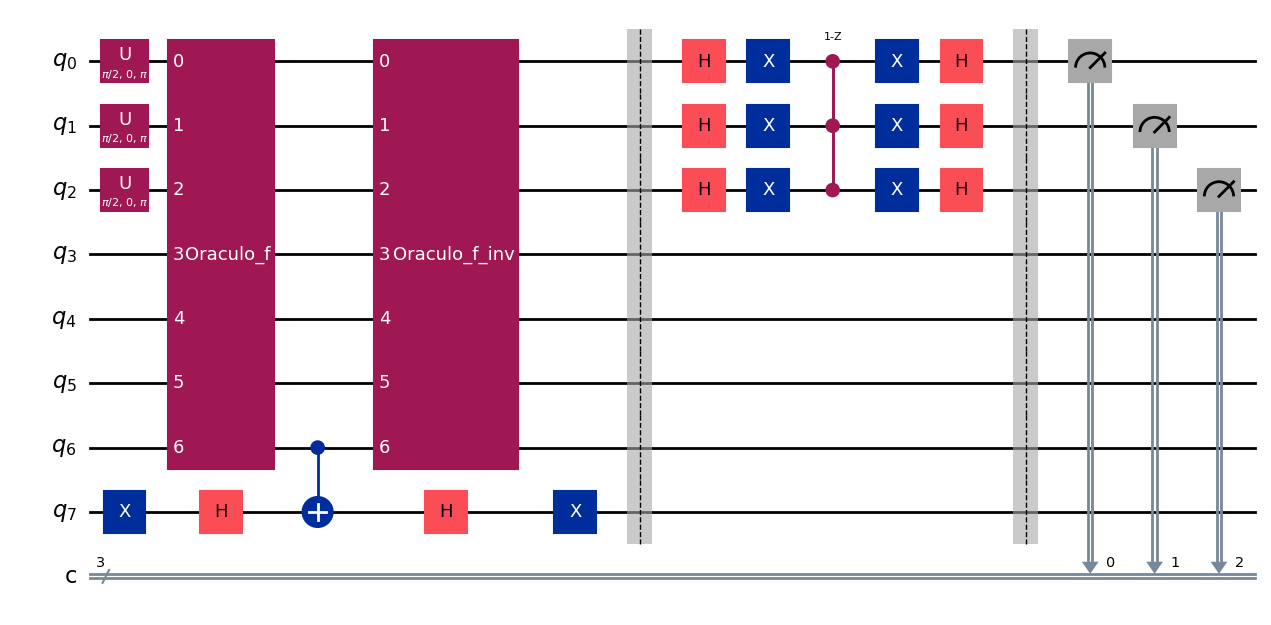

In [12]:
# Algoritmo de Grover completo
k = len(soluciones)  # numero de soluciones de f, calculado por fuerza bruta arriba
niters = int((np.pi / 4) * np.sqrt(2**N_INPUT / k))
print("Numero de soluciones k =", k)
print("Numero de iteraciones =", niters)

qc = QuantumCircuit(N_TOTAL, N_INPUT)
qc.h(range(N_INPUT))

for _ in range(niters):
    qc.append(inversor_grover_f(), range(N_TOTAL))
    qc.barrier()
    qc.append(difusor_grover(N_INPUT), range(N_INPUT))
    qc.barrier()

qc.measure(range(N_INPUT), range(N_INPUT))
display(qc.decompose().draw('mpl'))


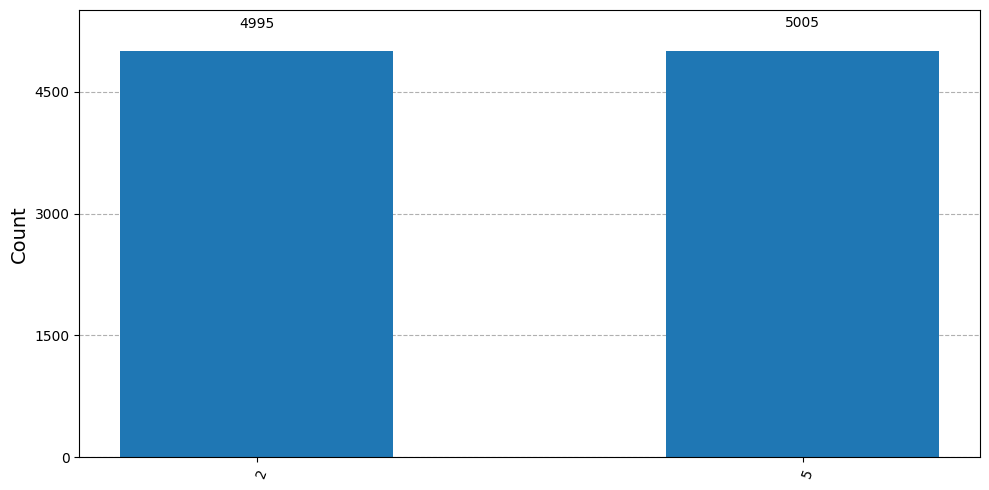

In [13]:
sampler = Sampler()
job = sampler.run([qc.decompose(reps=6)], shots=10000)
result = job.result()[0]
salida = result.data.c.get_int_counts()
plot_histogram(salida, figsize=(10, 5))


In [14]:
print("Soluciones esperadas (fuerza bruta):", soluciones)
print("Valores obtenidos por Grover:", sorted(salida.keys()))


Soluciones esperadas (fuerza bruta): [(0, 1, 0), (1, 0, 1)]
Valores obtenidos por Grover: [2, 5]
